# Machine Learning I

##  Predição de Balneabilidade com variáveis climáticas

Inspiração: Predizer a qualidade da água para uma praia específica do estado de São Paulo.  

Consultando alguns datasets presentes na Kaggle, o dataset de balneabilidade estava bastante completo com várias anos de dados. Além do mais, esse dataset instiga a trabalhar com séries temporais, que são muito mais difícieis de predizer do que dataset sem séries temporais. Aqui vamos diretamente trabalhar em cenários mais difíceis. 

Dataset: [Balneabilidade no estado de Sao Paulo](https://www.kaggle.com/datasets/amandalk/sp-beaches-water-quality)

O dataset contém um série de praias os dados de qualidade de água para um parâmetro: *Enterococcus*. Esse é um parâmetro bastante importante em qualidade da água pois é um biondicador de despejo de esgotamento sanitário.

Contudo, esse dataset não possui nenhuma variável preditora, para isso, fizemos uma preparação do dataset no notebook [dataset_preparation.ipynb](ml-dl/dataset_preparation.ipynb) e baixamos os dados de ERA5, diretamente do Earth Data Hub. Captamos 7 variáveis para utilizar como variáveis preditoras, são elas: 
- Total precipitation (tp) - Precipitao Total. 
- Runoff (ro) - Escoamento Superficial
- Top Soil Moisture (swl1) - Umidade superficial do solo
- Temperature 2m - (t2m) - Temperatura a 2 metros
- Downward Solar Radiation (ssrd) - Radiação Solar 
- U10 e v10, são as duas componentes ortogonais do vento, que é transformada em velocidade do vento. 

Contudo, a ideia é para cada variável, buscarmos os **7 dias antecedentes a coleta**. Dessa forma, temos 6 variáveis climáticas com 7 dias anteriores, totalizando 42 variáveis preditoras para nosso pipeline de Machine-Leaning.

Antes de partirmos, vamos pensar em conjunto, será que utilizando APENAS variáveis climáticas, seria passível de predizer se uma praia específica será imprópria para banho no dia seguinte? 

Poderíamos fazer isso facilmente para todas as praias de SP, mas para evitar um volume muito grande de dados aqui, vamos focar na praia do Perequê em Guarujá, SP.


Nesta aula vamos percorrer o fluxo padrão de um projeto de *machine learning* supervisionado:

1. Definir o **alvo** (a classe que queremos prever) e checar se as classes estão **balanceadas**
2. Separar **treino** e **teste** respeitando o **tempo**
3. Montar **pipelines** (pré-processamento + modelo) com o `sklearn`
4. Otimizar hiperparâmetros com **Grid Search** e **validação cruzada** (4 folds)
5. **Retreinar** o melhor modelo em todo o treino
6. **Avaliar** no teste: matriz de confusão, precisão, *recall* e F1
7. **Selecionar features** e ver como menos variáveis afetam o desempenho
8. **Interpretar** o melhor modelo: quais variáveis influenciam a previsão, e em que direção

Os dados vêm do notebook `dataset_preparation.ipynb`: 445 coletas de Enterococcus da CETESB (2012–2021) e,
para cada coleta, 7 variáveis do ERA5-Land em cada um dos 7 dias anteriores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.inspection import permutation_importance

# cores e estilo dos gráficos
AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

SEED = 42

## Carregar o dataset

In [ ]:
dataset = pd.read_parquet("data/pereque_guaruja_era5_window7.parquet")
dataset = dataset.sort_values("Date").reset_index(drop=True)   # a ordem temporal importa
print(dataset.shape)
dataset.head()

(445, 55)


,City,Beach,Date,Enterococcus,tp_mm_day_7,ro_mm_day_7,swvl1_day_7,t2m_c_day_7,ssrd_mj_day_7,wind_speed_day_7,...,wind_onshore_day_2,tp_mm_day_1,ro_mm_day_1,swvl1_day_1,t2m_c_day_1,ssrd_mj_day_1,wind_speed_day_1,wind_onshore_day_1,tp_mm_sum_3d,tp_mm_sum_7d
0,GUARUJÁ,PEREQUÊ,2012-01-03,560.0,0.660896,1.351357,0.390381,21.873444,23.740416,1.739490,...,-0.556320,2.584457,1.353264,0.411865,21.748444,21.823488,3.616360,-0.770633,46.667099,51.984787
1,GUARUJÁ,PEREQUÊ,2012-01-08,440.0,27.175903,9.468079,0.424561,23.475006,13.230080,1.432132,...,1.556386,10.330200,1.836777,0.393311,24.029694,24.248320,0.314128,0.310074,17.706394,47.587513
2,GUARUJÁ,PEREQUÊ,2012-01-15,228.0,5.432129,1.411438,0.401123,23.092194,20.725760,1.217795,...,0.183443,0.972748,1.166344,0.373047,26.623444,16.678911,2.901690,-0.016875,5.425096,34.943222
3,GUARUJÁ,PEREQUÊ,2012-01-22,320.0,14.640808,3.261566,0.395020,25.310944,16.359425,1.284021,...,0.958184,16.357422,7.972717,0.420654,25.068756,24.608768,0.821181,0.306810,46.501160,131.713867
4,GUARUJÁ,PEREQUÊ,2012-01-29,104.0,1.498222,2.056122,0.414307,24.451569,15.360000,1.273596,...,1.071924,4.589081,5.233765,0.417480,20.482819,19.234816,1.847250,-0.491982,82.912445,116.492271


In [3]:
dataset.columns

Index(['City', 'Beach', 'Date', 'Enterococcus', 'tp_mm_day_7', 'ro_mm_day_7',
       'swvl1_day_7', 't2m_c_day_7', 'ssrd_mj_day_7', 'wind_speed_day_7',
       'wind_onshore_day_7', 'tp_mm_day_6', 'ro_mm_day_6', 'swvl1_day_6',
       't2m_c_day_6', 'ssrd_mj_day_6', 'wind_speed_day_6',
       'wind_onshore_day_6', 'tp_mm_day_5', 'ro_mm_day_5', 'swvl1_day_5',
       't2m_c_day_5', 'ssrd_mj_day_5', 'wind_speed_day_5',
       'wind_onshore_day_5', 'tp_mm_day_4', 'ro_mm_day_4', 'swvl1_day_4',
       't2m_c_day_4', 'ssrd_mj_day_4', 'wind_speed_day_4',
       'wind_onshore_day_4', 'tp_mm_day_3', 'ro_mm_day_3', 'swvl1_day_3',
       't2m_c_day_3', 'ssrd_mj_day_3', 'wind_speed_day_3',
       'wind_onshore_day_3', 'tp_mm_day_2', 'ro_mm_day_2', 'swvl1_day_2',
       't2m_c_day_2', 'ssrd_mj_day_2', 'wind_speed_day_2',
       'wind_onshore_day_2', 'tp_mm_day_1', 'ro_mm_day_1', 'swvl1_day_1',
       't2m_c_day_1', 'ssrd_mj_day_1', 'wind_speed_day_1',
       'wind_onshore_day_1', 'tp_mm_sum_3d', 'tp_m

## Definir as variáveis alvo diante de uma classificação binária

A Resolução CONAMA 274/2000 usa Enterococcus para classificar a balneabilidade. Aqui vamos adotar a seguinte regra:

| Enterococcus (UFC/100 mL) | Classe | Rótulo |
|---|---|---|
| ≤ 200 | **Própria** (água boa) | 0 |
| > 200 | **Imprópria** (água ruim) | 1 |

A classe **1 (imprópria)** é a classe *positiva*: é o evento que queremos detectar.

In [9]:
LIMIAR = 400
dataset["impropria"] = (dataset["Enterococcus"] > LIMIAR).astype(int)
NOMES_CLASSES = ["Própria (0)", "Imprópria (1)"]

dataset["impropria"].value_counts().rename(index=dict(enumerate(NOMES_CLASSES)))

impropria
Própria (0)      249
Imprópria (1)    196
Name: count, dtype: int64

### O dataset está balanceado?

Um dataset é **desbalanceado** quando uma classe aparece muito mais que a outra. Isso importa porque um
modelo que sempre chuta a classe majoritária já acerta muito, e parece bom sem ter aprendido nada.

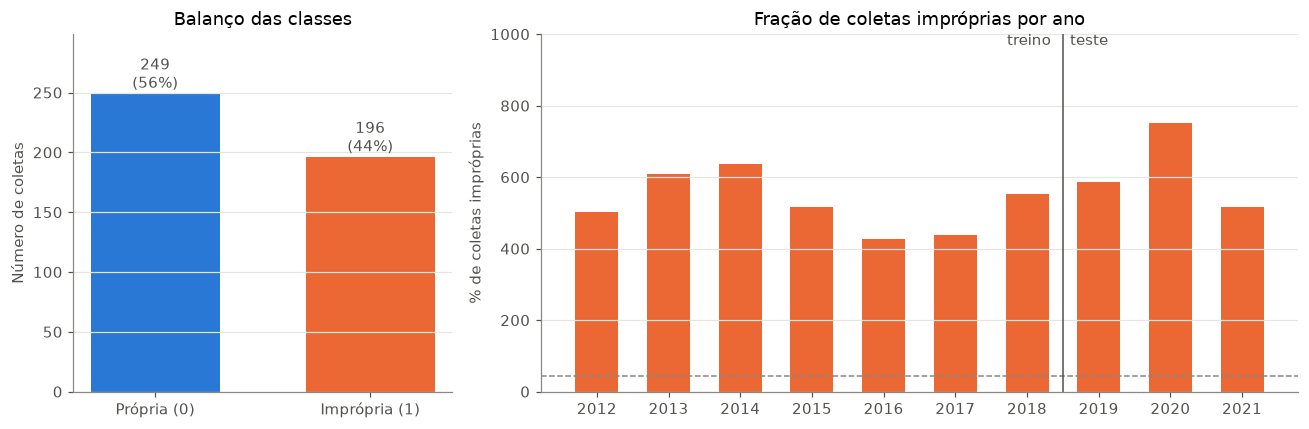

In [23]:
contagem = dataset["impropria"].value_counts().sort_index()
por_ano = dataset.groupby(dataset["Date"].dt.year)["Enterococcus"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 2])

axes[0].bar(NOMES_CLASSES, contagem.values, color=[AZUL, LARANJA], width=0.6)
for x, n in enumerate(contagem.values):
    axes[0].text(x, n + 5, f"{n}\n({n / contagem.sum():.0%})", ha="center", color=TINTA)
axes[0].set(ylabel="Número de coletas", title="Balanço das classes", ylim=(0, contagem.max() * 1.2))
axes[0].grid(axis="x", visible=False)

axes[1].bar(por_ano.index, por_ano.values, color=LARANJA, width=0.6)
axes[1].axhline(dataset["impropria"].mean() * 100, color=CINZA, ls="--", lw=1)
axes[1].axvline(2018.5, color=TINTA, lw=1)
axes[1].text(2018.4, 970, "treino ", ha="right", color=TINTA)
axes[1].text(2018.6, 970, "teste", ha="left", color=TINTA)
axes[1].set(ylabel="% de coletas impróprias", title="Fração de coletas impróprias por ano",
            ylim=(0, 1000), xticks=por_ano.index)
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

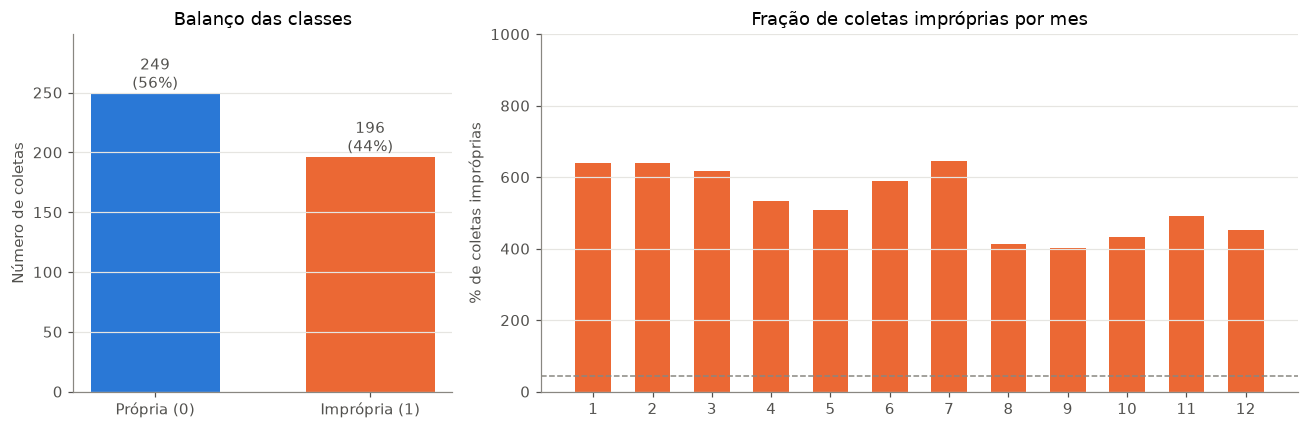

In [25]:
# efeito da sazonilidade 
contagem = dataset["impropria"].value_counts().sort_index()
por_mes = dataset.groupby(dataset["Date"].dt.month)["Enterococcus"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 2])

axes[0].bar(NOMES_CLASSES, contagem.values, color=[AZUL, LARANJA], width=0.6)
for x, n in enumerate(contagem.values):
    axes[0].text(x, n + 5, f"{n}\n({n / contagem.sum():.0%})", ha="center", color=TINTA)
axes[0].set(ylabel="Número de coletas", title="Balanço das classes", ylim=(0, contagem.max() * 1.2))
axes[0].grid(axis="x", visible=False)

axes[1].bar(por_mes.index, por_mes.values, color=LARANJA, width=0.6)
axes[1].axhline(dataset["impropria"].mean() * 100, color=CINZA, ls="--", lw=1)
axes[1].set(ylabel="% de coletas impróprias", title="Fração de coletas impróprias por mes",
            ylim=(0, 1000), xticks=por_mes.index)
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## Variáveis preditoras (features)

Usamos as 7 variáveis do ERA5-Land em cada um dos 7 dias anteriores (`day_7` ... `day_1`) e os acumulados
de chuva. Na análise exploratória vimos que existe uma certa **sazonalidade**, por isso
adicionamos o **mês** codificado de forma cíclica:

$$\text{mes\_sin} = \sin\left(\frac{2\pi \cdot \text{mês}}{12}\right), \qquad \text{mes\_cos} = \cos\left(\frac{2\pi \cdot \text{mês}}{12}\right)$$

Assim dezembro (12) fica "perto" de janeiro (1), o que não aconteceria usando o número do mês direto.

In [26]:
mes = dataset["Date"].dt.month
dataset["mes_sin"] = np.sin(2 * np.pi * mes / 12)
dataset["mes_cos"] = np.cos(2 * np.pi * mes / 12)

NAO_FEATURES = ["City", "Beach", "Date", "Enterococcus", "impropria"]
FEATURES = [c for c in dataset.columns if c not in NAO_FEATURES]
print(f"{len(FEATURES)} features")
FEATURES[:10]

53 features


['tp_mm_day_7',
 'ro_mm_day_7',
 'swvl1_day_7',
 't2m_c_day_7',
 'ssrd_mj_day_7',
 'wind_speed_day_7',
 'wind_onshore_day_7',
 'tp_mm_day_6',
 'ro_mm_day_6',
 'swvl1_day_6']

## Split do treino e teste respeitando o tempo

Em séries temporais **não** podemos embaralhar os dados antes de separar. Se misturarmos, o modelo treina com
coletas de 2020 e é testado em 2015: ele "vê o futuro", e a nota no teste fica otimista demais
(*data leakage*). Na vida real, treinamos com o passado e prevemos o futuro.

- **Treino (e validação):** 2012–2018 - equivalente a  80% das coletas
- **Teste:** 2019–2021 - equivalente 20% das coletas, guardados a sete chaves até o final

In [37]:
treino = dataset["Date"].dt.year <= 2018

X_train, y_train = dataset.loc[treino, FEATURES], dataset.loc[treino, "impropria"]
X_test, y_test = dataset.loc[~treino, FEATURES], dataset.loc[~treino, "impropria"]
datas_train, datas_test = dataset.loc[treino, "Date"], dataset.loc[~treino, "Date"]

pd.DataFrame({
    "coletas": [len(y_train), len(y_test)],
    "% do total": [len(y_train) / len(dataset) * 100, len(y_test) / len(dataset) * 100],
    "% impróprias": [y_train.mean() * 100, y_test.mean() * 100],
    "período": [f"{datas_train.min():%Y-%m} a {datas_train.max():%Y-%m}", f"{datas_test.min():%Y-%m} a {datas_test.max():%Y-%m}"],
}, index=["treino", "teste"]).round(1)

,coletas,% do total,% impróprias,período
treino,356,80.0,43.5,2012-01 a 2018-12
teste,89,20.0,46.1,2019-01 a 2021-07


`Deem uma olhada na função: train_test_split do SKlearn!`

[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_s = dataset.drop(columns=['Enterococcus','impropria']).sort_values(by=['Date'])
Y_target = dataset['impropria']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_train_s, Y_target, shuffle=False, test_size=0.2)

## qual é o problema aqui? 
#X_train_s['Date'].max()

## Validação cruzada temporal (4 folds)

Como vimos na aula teórica, para escolher hiperparâmetros precisamos de dados de **validação**, sem tocar no teste. 

A validação cruzada divide o treino em *k* partes (*folds*) e avalia o modelo *k* vezes.

No `KFold` comum os folds são embaralhados e o modelo pode treinar no futuro e validar no passado. Com dados
temporais usamos o `TimeSeriesSplit`, conseguimos conservar que em cada fold o modelo treina com tudo que veio *antes* e valida no
bloco *seguinte*. O treino vai crescendo a cada fold.

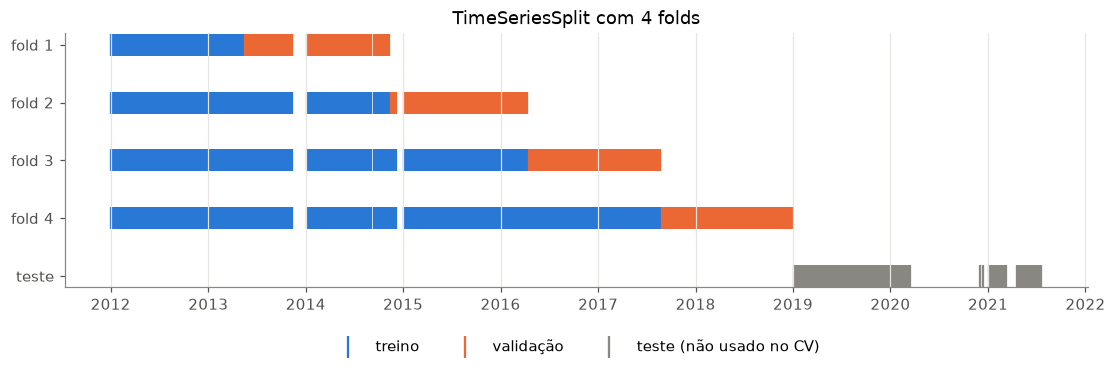

In [42]:
# cria a classe de Time series split
cv = TimeSeriesSplit(n_splits=4)

# a classe funciona atraves do metodo split
fig, ax = plt.subplots(figsize=(12, 3))
for i, (idx_tr, idx_val) in enumerate(cv.split(X_train)):
    ax.scatter(datas_train.iloc[idx_tr], [i] * len(idx_tr), color=AZUL, marker="|", s=200, label="treino" if i == 0 else None)
    ax.scatter(datas_train.iloc[idx_val], [i] * len(idx_val), color=LARANJA, marker="|", s=200, label="validação" if i == 0 else None)
ax.scatter(datas_test, [4] * len(datas_test), color=CINZA, marker="|", s=200, label="teste (não usado no CV)")
ax.set(yticks=range(5), yticklabels=[f"fold {i + 1}" for i in range(4)] + ["teste"], title="TimeSeriesSplit com 4 folds")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=3)
plt.show()

## Pré-processamento e modelo em um objeto só

Vamos utilizar uma classe bastante pertinente para manter um código limpo e legível, essa classe é o `Pipeline` que serve para encadeiar as etapas de maneira lógica. Aqui cada pipeline tem duas:

1. `StandardScaler`: **padronização**, deixa cada feature com média 0 e desvio padrão 1:  $z = \frac{x - \mu}{\sigma}$
2. o **classificador**

Por que isso importa tanto? 

- **Evita vazamento:** dentro da validação cruzada, o `StandardScaler` calcula $\mu$ e $\sigma$ **só com os
  dados de treino de cada fold**. Se padronizássemos o dataset inteiro antes, a validação espiaria a média do futuro (data leak).
- **Organização:** trocar de algoritmo é trocar uma peça; o resto do código fica igual.
- **Escala:** KNN, SVM e regressão logística dependem de distâncias ou de pesos, então variáveis em escalas
  diferentes (radiação em MJ/m², chuva em mm) distorceriam o modelo. Árvores não precisam, mas mantemos
  o mesmo formato para todos.

In [8]:
# exemplo: um pipeline simples
exemplo = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=5000)),
])
exemplo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure 

## Métrica de otimização: F1

Já vimos que a **acurácia** pode enganar. Dessa forma, vamos partir para o **F1**, e combinar com duas perguntas:

- **Precisão:** das vezes que o modelo disse "imprópria", quantas eram mesmo? $\frac{TP}{TP + FP}$
- **Recall (sensibilidade):** das coletas realmente impróprias, quantas o modelo pegou? $\frac{TP}{TP + FN}$
- **F1:** média harmônica das duas, $F1 = 2 \cdot \frac{\text{precisão} \cdot \text{recall}}{\text{precisão} + \text{recall}}$

O F1 é calculado **para uma classe**. Temos duas opções:

| `scoring` | O que mede |
|---|---|
| `"f1"` | F1 APENAS da classe positiva (imprópria) |
| `"f1_macro"` | média simples do F1 da classe imprópria e do F1 da classe própria |

### Baseline: o modelo Dummy

Antes de qualquer algoritmo, medimos um `DummyClassifier` que **sempre** responde "imprópria". Qualquer modelo
de verdade precisa **superar** esse valor para valer a pena.

In [43]:
baseline = Pipeline([("scaler", StandardScaler()), ("modelo", DummyClassifier(strategy="constant", constant=1))])

for scoring in ["f1", "f1_macro"]:
    s = cross_val_score(baseline, X_train, y_train, cv=cv, scoring=scoring)
    print(f"Baseline, {scoring:<9}: {s.mean():.3f} ± {s.std():.3f}")

Baseline, f1       : 0.599 ± 0.053
Baseline, f1_macro : 0.300 ± 0.026


In [ ]:
METRICA = "f1_macro"
f1_baseline_cv = cross_val_score(baseline, 
                                 X_train, 
                                 y_train, 
                                 cv=cv, 
                                 scoring=METRICA)

## Hiperparâmetros

| Algoritmo | Ideia | Hiperparâmetros testados |
|---|---|---|
| **Regressão Logística** | fronteira linear; dá a probabilidade da classe | `C` (inverso da regularização), `l1_ratio` (0 = L2/Ridge, 1 = L1/Lasso) |
| **KNN** | vota com os *k* vizinhos mais parecidos | `n_neighbors`, peso dos vizinhos |
| **SVM (RBF)** | fronteira não linear com margem máxima | `C`, `gamma` |
| **Árvore de Decisão** | sequência de perguntas "sim/não" sobre as features | profundidade, mínimo de amostras por folha |
| **Random Forest** | média de muitas árvores treinadas em amostras diferentes | profundidade, folhas, nº de features por divisão |
| **Gradient Boosting** | árvores em sequência, cada uma corrigindo o erro da anterior | nº de árvores, taxa de aprendizado, profundidade |

`class_weight="balanced"` dá mais peso à classe minoritária (própria) no treino, uma forma simples de lidar
com o desbalanceamento. Deixamos o Grid Search decidir se usa ou não.

Nos pipelines, o nome da etapa + `__` + nome do parâmetro indica a qual peça o hiperparâmetro pertence:
`modelo__C` é o `C` da etapa `"modelo"`.

In [45]:
def pipeline(modelo):
    return Pipeline([("scaler", StandardScaler()), ("modelo", modelo)])

modelos = {
    "Regressão Logística": (
        pipeline(LogisticRegression(solver="liblinear", max_iter=5000)),
        {"modelo__C": [0.001, 0.01, 0.1, 1, 10],
         "modelo__l1_ratio": [0, 1],
         "modelo__class_weight": [None, "balanced"]},
    ),
    "KNN": (
        pipeline(KNeighborsClassifier()),
        {"modelo__n_neighbors": [3, 5, 11, 21, 31],
         "modelo__weights": ["uniform", "distance"]},
    ),
    "SVM": (
        pipeline(SVC(kernel="rbf", random_state=SEED)),
        {"modelo__C": [0.1, 1, 10],
         "modelo__gamma": ["scale", 0.01, 0.001],
         "modelo__class_weight": [None, "balanced"]},
    ),
    "Árvore de Decisão": (
        pipeline(DecisionTreeClassifier(random_state=SEED)),
        {"modelo__max_depth": [2, 3, 5, 8, None],
         "modelo__min_samples_leaf": [1, 5, 10, 20],
         "modelo__class_weight": [None, "balanced"]},
    ),
    "Random Forest": (
        pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
        {"modelo__max_depth": [3, 5, 10, None],
         "modelo__min_samples_leaf": [1, 5, 10],
         "modelo__max_features": ["sqrt", 0.3],
         "modelo__class_weight": [None, "balanced"]},
    ),
    "Gradient Boosting": (
        pipeline(GradientBoostingClassifier(random_state=SEED)),
        {"modelo__n_estimators": [100, 300],
         "modelo__learning_rate": [0.01, 0.05, 0.1],
         "modelo__max_depth": [2, 3]},
    ),
}

for nome, (_, grade) in modelos.items():
    n = np.prod([len(v) for v in grade.values()])
    print(f"{nome:<20} {n:>3} combinações × 4 folds = {n * 4:>3} treinos")

Regressão Logística   20 combinações × 4 folds =  80 treinos
KNN                   10 combinações × 4 folds =  40 treinos
SVM                   18 combinações × 4 folds =  72 treinos
Árvore de Decisão     40 combinações × 4 folds = 160 treinos
Random Forest         48 combinações × 4 folds = 192 treinos
Gradient Boosting     12 combinações × 4 folds =  48 treinos


## Grid Search com validação cruzada

Para cada algoritmo, o `GridSearchCV` testa **todas** as combinações da grade. Cada combinação é treinada e
validada nos 4 folds temporais, e a melhor é a de maior **F1 macro médio na validação**.

In [46]:
buscas = {}
for nome, (pipe, grade) in modelos.items():
    busca = GridSearchCV(pipe, grade, cv=cv, scoring=METRICA, refit=False, n_jobs=-1)
    busca.fit(X_train, y_train)
    buscas[nome] = busca
    print(f"{nome:<20} F1 macro validação = {busca.best_score_:.3f}   {busca.best_params_}")

Regressão Logística  F1 macro validação = 0.570   {'modelo__C': 0.01, 'modelo__class_weight': None, 'modelo__l1_ratio': 0}
KNN                  F1 macro validação = 0.496   {'modelo__n_neighbors': 5, 'modelo__weights': 'uniform'}
SVM                  F1 macro validação = 0.576   {'modelo__C': 10, 'modelo__class_weight': 'balanced', 'modelo__gamma': 0.01}
Árvore de Decisão    F1 macro validação = 0.559   {'modelo__class_weight': 'balanced', 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 1}
Random Forest        F1 macro validação = 0.534   {'modelo__class_weight': 'balanced', 'modelo__max_depth': 5, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1}
Gradient Boosting    F1 macro validação = 0.505   {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}


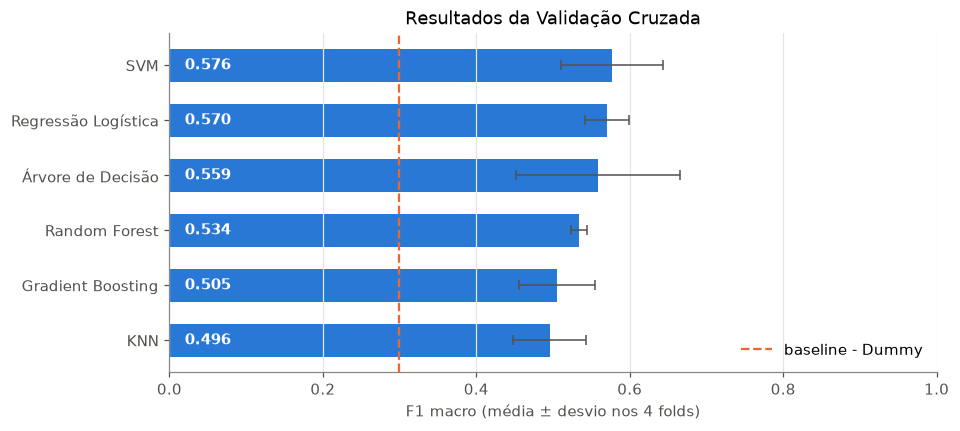

Modelo escolhido pela validação cruzada: SVM


In [50]:
# resultados da validação cruzada, média e desvio nos 4 folds, para a melhor combinação de cada modelo
res_cv = pd.DataFrame({
    nome: {"F1 macro (validação)": b.best_score_,
           "desvio": b.cv_results_["std_test_score"][b.best_index_]}
    for nome, b in buscas.items()
}).T.sort_values("F1 macro (validação)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(res_cv.index, res_cv["F1 macro (validação)"], xerr=res_cv["desvio"], color=AZUL, height=0.6,
        error_kw={"ecolor": TINTA, "lw": 1, "capsize": 3})
ax.axvline(f1_baseline_cv.mean(), color=LARANJA, ls="--", lw=1.5, label="baseline - Dummy")
ax.legend(frameon=False, loc="lower right")
for y, v in enumerate(res_cv["F1 macro (validação)"]):
    ax.text(0.02, y, f"{v:.3f}", va="center", color="white", fontweight="bold")
ax.set(xlabel="F1 macro (média ± desvio nos 4 folds)", xlim=(0, 1), title="Resultados da Validação Cruzada")
ax.grid(axis="y", visible=False)
plt.show()

# o modelo escolhido é o melhor na VALIDAÇÃO, nunca no teste
melhor = res_cv["F1 macro (validação)"].idxmax()
print(f"Modelo escolhido pela validação cruzada: {melhor}")

## Retreinar com todo o treino

Durante o CV, cada modelo só viu parte do treino. Agora que conhecemos os melhores hiperparâmetros,
**retreinamos cada pipeline em todo o período 2012–2018**. `clone` cria uma cópia "zerada" do pipeline, e
`set_params` aplica os hiperparâmetros vencedores.

> Obs.: o `GridSearchCV` faz isso sozinho com `refit=True` (o padrão). Aqui deixamos explícito para
> ficar claro o que acontece.

In [51]:
finais = {"Baseline": clone(baseline).fit(X_train, y_train)}
for nome, (pipe, _) in modelos.items():
    finais[nome] = clone(pipe).set_params(**buscas[nome].best_params_).fit(X_train, y_train)
list(finais)

['Baseline',
 'Regressão Logística',
 'KNN',
 'SVM',
 'Árvore de Decisão',
 'Random Forest',
 'Gradient Boosting']

## 11. Avaliação no conjunto de teste (2019–2021)

Só agora usamos o teste, **uma única vez**. Ele simula o uso real: prever anos que o modelo nunca viu.

### Matriz de confusão

|  | Previsto: própria | Previsto: imprópria |
|---|---|---|
| **Real: própria** | Verdadeiro Negativo (VN) | Falso Positivo (FP): alarme falso, praia fechada à toa |
| **Real: imprópria** | Falso Negativo (FN): **risco à saúde**, banhista entra em água contaminada | Verdadeiro Positivo (VP) |

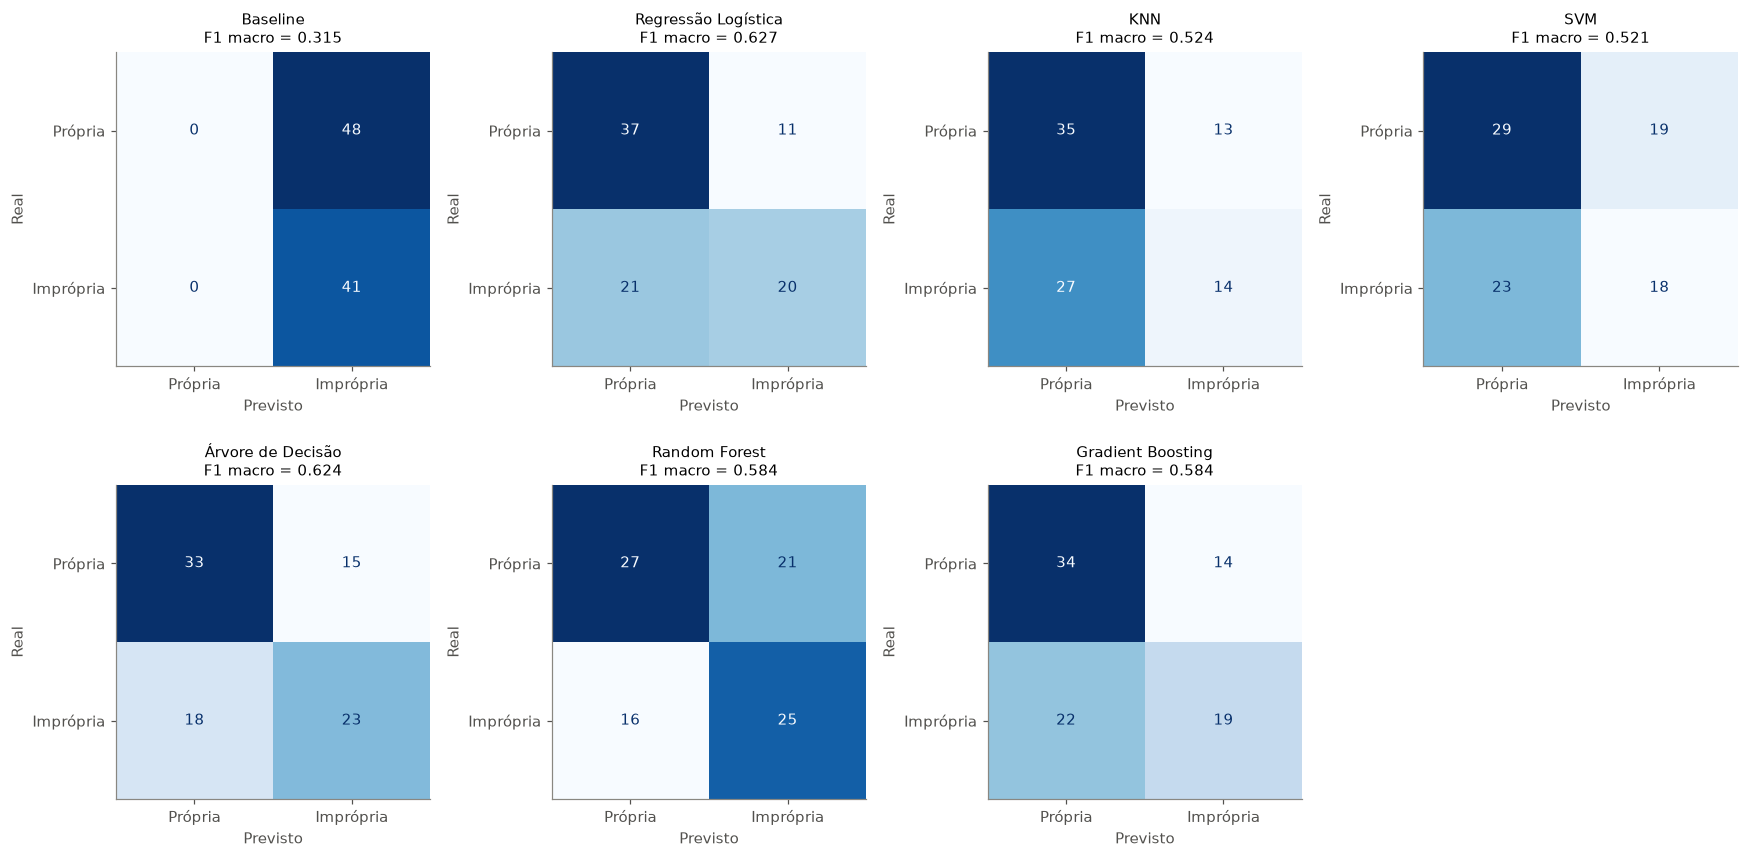

In [52]:
previsoes = {nome: m.predict(X_test) for nome, m in finais.items()}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (nome, y_pred) in zip(axes.flat, previsoes.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Própria", "Imprópria"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{nome}\nF1 macro = {f1_score(y_test, y_pred, average='macro'):.3f}", fontsize=10)
    ax.set(xlabel="Previsto", ylabel="Real")
    ax.grid(False)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### Precisão, recall e F1

Calculamos cada métrica para as duas classes e a média *macro* (a mesma usada na otimização).

In [53]:
def metricas_teste(y_true, y_pred):
    return {
        "Precisão (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "F1 imprópria": f1_score(y_true, y_pred, pos_label=1),
        "F1 própria": f1_score(y_true, y_pred, pos_label=0),
        "Recall imprópria": recall_score(y_true, y_pred, pos_label=1),
        "Recall própria": recall_score(y_true, y_pred, pos_label=0),
        "Acurácia": accuracy_score(y_true, y_pred),
    }

metricas = pd.DataFrame({nome: metricas_teste(y_test, y_pred) for nome, y_pred in previsoes.items()}).T
metricas = metricas.sort_values("F1 (macro)", ascending=False)
metricas.round(3)

,Precisão (macro),Recall (macro),F1 (macro),F1 imprópria,F1 própria,Recall imprópria,Recall própria,Acurácia
Regressão Logística,0.642,0.629,0.627,0.556,0.698,0.488,0.771,0.640
Árvore de Decisão,0.626,0.624,0.624,0.582,0.667,0.561,0.688,0.629
Random Forest,0.586,0.586,0.584,0.575,0.593,0.610,0.562,0.584
Gradient Boosting,0.591,0.586,0.584,0.514,0.654,0.463,0.708,0.596
KNN,0.542,0.535,0.524,0.412,0.636,0.341,0.729,0.551
SVM,0.522,0.522,0.521,0.462,0.580,0.439,0.604,0.528
Baseline,0.230,0.500,0.315,0.631,0.000,1.000,0.000,0.461


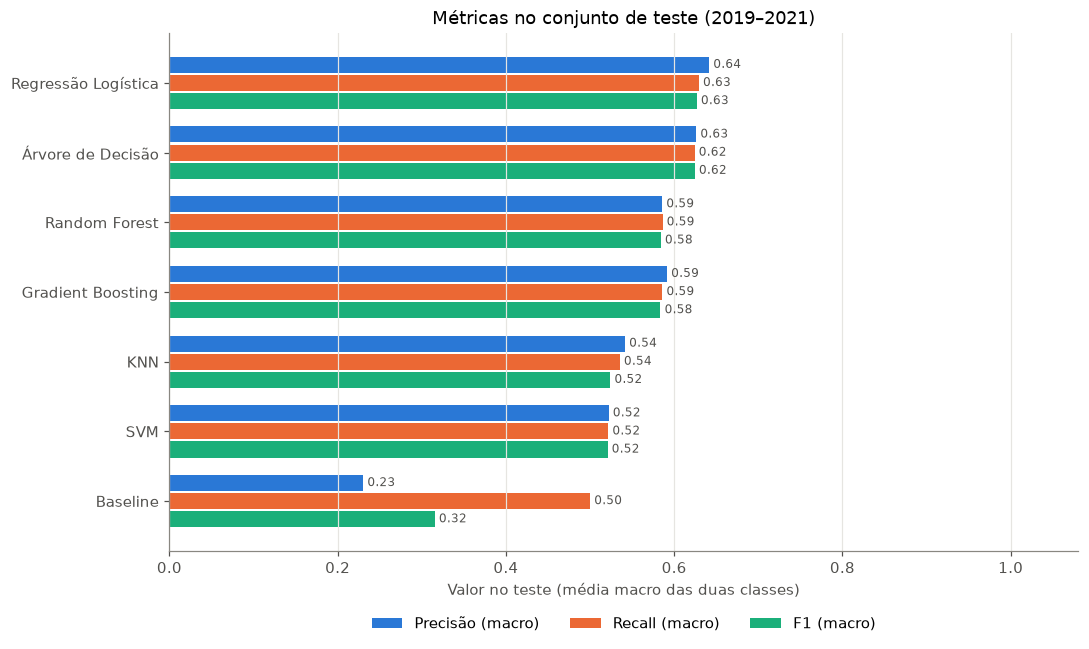

In [54]:
plot_df = metricas[["Precisão (macro)", "Recall (macro)", "F1 (macro)"]].iloc[::-1]
y = np.arange(len(plot_df))
altura = 0.26

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metrica, cor) in enumerate(zip(plot_df.columns, [AZUL, LARANJA, VERDE])):
    pos = y + (1 - i) * altura
    ax.barh(pos, plot_df[metrica], height=altura - 0.03, color=cor, label=metrica)
    for p, v in zip(pos, plot_df[metrica]):
        ax.text(v + 0.005, p, f"{v:.2f}", va="center", fontsize=8, color=TINTA)
ax.set(yticks=y, yticklabels=plot_df.index, xlim=(0, 1.08), xlabel="Valor no teste (média macro das duas classes)",
       title="Métricas no conjunto de teste (2019–2021)")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=3)
plt.tight_layout()
plt.show()

In [56]:
melhor

'SVM'

In [55]:
# relatório completo do modelo escolhido pela validação cruzada
print(f"Modelo escolhido: {melhor}\n")
print(classification_report(y_test, previsoes[melhor], target_names=["Própria", "Imprópria"], digits=3))

Modelo escolhido: SVM

              precision    recall  f1-score   support

     Própria      0.558     0.604     0.580        48
   Imprópria      0.486     0.439     0.462        41

    accuracy                          0.528        89
   macro avg      0.522     0.522     0.521        89
weighted avg      0.525     0.528     0.525        89



## Quais variáveis o modelo escolhido usa?

A **importância por permutação** embaralha uma feature de cada vez e mede quanto o F1 macro cai. Se o F1 cai
muito, o modelo depende daquela variável.

Calculamos a importância nos dados de **treino**. Na próxima seção vamos usar esse ranking para escolher
features, e qualquer escolha feita olhando o teste contaminaria a avaliação final (*data leakage*).

In [86]:
melhor ="Random Forest"

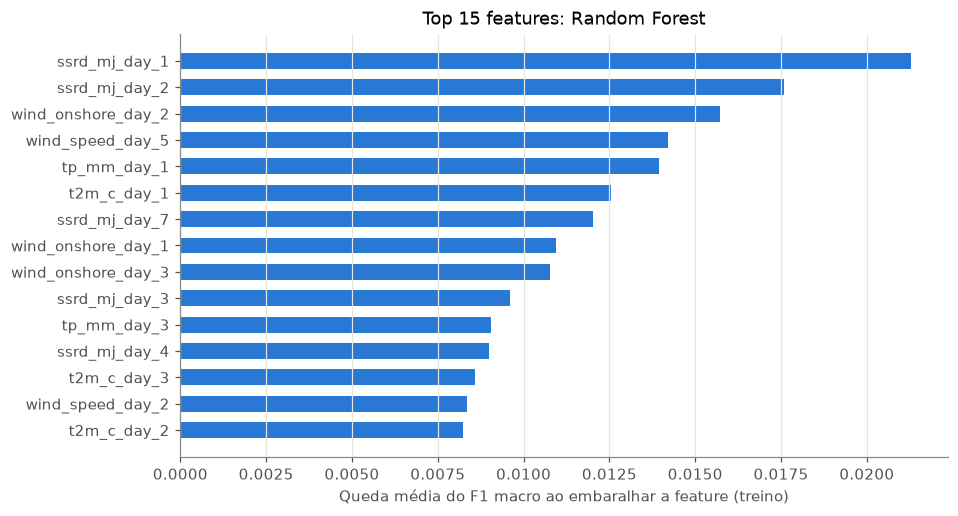

In [87]:
imp = permutation_importance(finais[melhor], X_train, 
                             y_train, 
                             scoring=METRICA, 
                             n_repeats=50, 
                             random_state=15, 
                             n_jobs=-1
                             )
importancia = pd.Series(imp.importances_mean, index=FEATURES).sort_values(ascending=False)
top = importancia.head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top.values, color=AZUL, height=0.6)
ax.axvline(0, color=CINZA, lw=1)
ax.set(xlabel="Queda média do F1 macro ao embaralhar a feature (treino)", title=f"Top 15 features: {melhor}")
ax.grid(axis="y", visible=False)
plt.show()

## Menos é mais? Retreinar só com as 15 features mais importantes

Até aqui usamos **53 features** para apenas **356 coletas de treino**. Diante dessa features, muitas delas acaba, representando a quase a mesma coisa:

- a umidade do solo de hoje é muito parecida com a de ontem (variáveis **autocorrelacionadas** no tempo);
- chuva, escoamento e umidade do solo do mesmo dia andam juntos (**multicolinearidade**).

Features redundantes não trazem informação nova, mas trazem **ruído** e mais parâmetros para ajustar. Com
poucos dados, isso aumenta o risco de *overfitting*, e modelos baseados em distância (KNN, SVM) sofrem com a
**maldição da dimensionalidade** em que quando utilizamos muitas dimensões, todos os pontos ficam "longe" uns dos outros.

Primeiro, vamos ver o quanto as features são correlacionadas entre si.

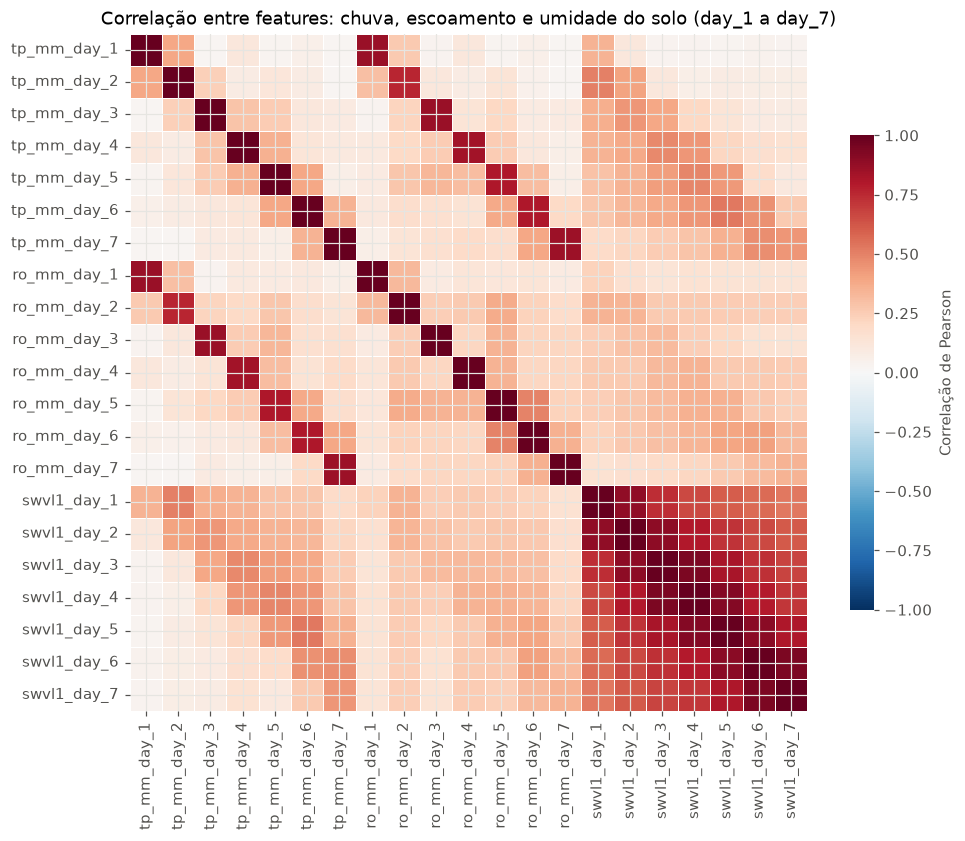

1378 pares de features
37 pares com |r| > 0.7 (3%)
4 pares com |r| > 0.9 (0%)


In [82]:
# correlação entre as features de chuva, escoamento e umidade do solo nos 7 dias
grupo = [f"{v}_day_{d}" for v in ["tp_mm", "ro_mm", "swvl1"] for d in range(1, 8)]
corr_grupo = X_train[grupo].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_grupo, cmap="RdBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Correlação de Pearson", "shrink": 0.7}, ax=ax)
ax.set_title("Correlação entre features: chuva, escoamento e umidade do solo (day_1 a day_7)")
plt.show()

# quantos pares de features (entre todas as 53) são fortemente correlacionados?
corr_abs = X_train[FEATURES].corr().abs().to_numpy()
pares = corr_abs[np.triu_indices_from(corr_abs, k=1)]
print(f"{len(pares)} pares de features")
print(f"{(pares > 0.7).sum()} pares com |r| > 0.7 ({(pares > 0.7).mean():.0%})")
print(f"{(pares > 0.9).sum()} pares com |r| > 0.9 ({(pares > 0.9).mean():.0%})")

**Leitura:** a umidade do solo forma um bloco quase todo vermelho: o valor de um dia praticamente repete o do
dia anterior. Chuva e escoamento do mesmo dia também andam juntos.

Agora selecionamos as **15 features mais importantes** do ranking da seção 12 e repetimos **exatamente** o
mesmo processo: mesmos pipelines, mesma grade de hiperparâmetros, mesma validação cruzada e mesmo teste. Só
muda a lista de colunas.

In [88]:
TOP_FEATURES = list(importancia.head(10).index)
X_train_top, X_test_top = X_train[TOP_FEATURES], X_test[TOP_FEATURES]
print(f"{len(FEATURES)} > {len(TOP_FEATURES)} features:")
TOP_FEATURES

53 > 10 features:


['ssrd_mj_day_1',
 'ssrd_mj_day_2',
 'wind_onshore_day_2',
 'wind_speed_day_5',
 'tp_mm_day_1',
 't2m_c_day_1',
 'ssrd_mj_day_7',
 'wind_onshore_day_1',
 'wind_onshore_day_3',
 'ssrd_mj_day_3']

In [89]:
# mesmo Grid Search + retreino, agora só com as 15 features
buscas_top, finais_top = {}, {}
for nome, (pipe, grade) in modelos.items():
    busca = GridSearchCV(pipe, grade, cv=cv, scoring=METRICA, refit=False, n_jobs=-1).fit(X_train_top, y_train)
    buscas_top[nome] = busca
    finais_top[nome] = clone(pipe).set_params(**busca.best_params_).fit(X_train_top, y_train)
    print(f"{nome:<20} F1 macro validação = {busca.best_score_:.3f}   {busca.best_params_}")

previsoes_top = {nome: m.predict(X_test_top) for nome, m in finais_top.items()}
metricas_top = pd.DataFrame({nome: metricas_teste(y_test, y_pred) for nome, y_pred in previsoes_top.items()}).T

Regressão Logística  F1 macro validação = 0.574   {'modelo__C': 0.01, 'modelo__class_weight': 'balanced', 'modelo__l1_ratio': 0}
KNN                  F1 macro validação = 0.523   {'modelo__n_neighbors': 11, 'modelo__weights': 'uniform'}
SVM                  F1 macro validação = 0.553   {'modelo__C': 1, 'modelo__class_weight': None, 'modelo__gamma': 'scale'}
Árvore de Decisão    F1 macro validação = 0.601   {'modelo__class_weight': 'balanced', 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 1}
Random Forest        F1 macro validação = 0.566   {'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1}
Gradient Boosting    F1 macro validação = 0.553   {'modelo__learning_rate': 0.01, 'modelo__max_depth': 2, 'modelo__n_estimators': 100}


In [ ]:
# comparação 53 features x top 15, na validação cruzada e no teste
comp = pd.DataFrame({
    "CV, 53 features": {n: buscas[n].best_score_ for n in modelos},
    "CV, top 15": {n: buscas_top[n].best_score_ for n in modelos},
    "Teste, 53 features": metricas.loc[list(modelos), "F1 (macro)"],
    "Teste, top 15": metricas_top.loc[list(modelos), "F1 (macro)"],
})
comp["Δ teste"] = comp["Teste, top 15"] - comp["Teste, 53 features"]
comp.sort_values("Teste, top 15", ascending=False).round(3)

,"CV, 53 features","CV, top 15","Teste, 53 features","Teste, top 15",Δ teste
Regressão Logística,0.570,0.574,0.627,0.643,0.016
Árvore de Decisão,0.559,0.601,0.624,0.624,0.000
SVM,0.576,0.553,0.521,0.595,0.074
Gradient Boosting,0.505,0.553,0.584,0.575,-0.009
KNN,0.496,0.523,0.524,0.557,0.033
Random Forest,0.534,0.566,0.584,0.534,-0.051


In [106]:
base

Regressão Logística    0.626834
Árvore de Decisão      0.624473
Random Forest          0.584060
Gradient Boosting      0.583680
KNN                    0.524064
SVM                    0.520769
Baseline               0.315385
Name: F1 (macro), dtype: float64

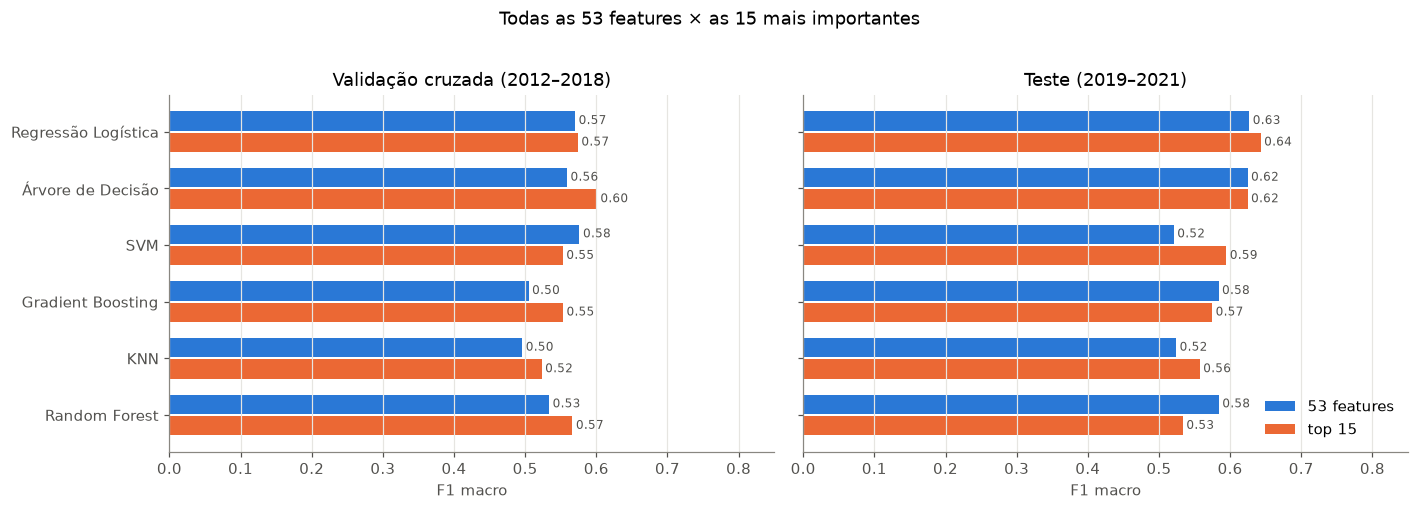

In [107]:
ordem = comp.sort_values("Teste, top 15").index
y = np.arange(len(ordem))
altura = 0.38
f1_baseline_teste = metricas["F1 (macro)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, etapa, base in zip(axes, ["CV", "Teste"], [f1_baseline_cv.mean(), f1_baseline_teste]):
    for i, (conjunto, cor) in enumerate([("53 features", AZUL), ("top 15", LARANJA)]):
        valores = comp.loc[ordem, f"{etapa}, {conjunto}"]
        pos = y + (0.5 - i) * altura
        ax.barh(pos, valores, height=altura - 0.04, color=cor, label=conjunto)
        for p, v in zip(pos, valores):
            ax.text(v + 0.005, p, f"{v:.2f}", va="center", fontsize=8, color=TINTA)
    #ax.axvline(base, color=CINZA, ls="--", lw=1.5, label="baseline")
    ax.set(xlim=(0, 0.85), xlabel="F1 macro",
           title="Validação cruzada (2012–2018)" if etapa == "CV" else "Teste (2019–2021)")
    ax.grid(axis="y", visible=False)
axes[0].set(yticks=y, yticklabels=ordem)
axes[1].legend(frameon=False, loc="lower right")
plt.suptitle("Todas as 53 features × as 15 mais importantes", y=1.02)
plt.tight_layout()
plt.show()

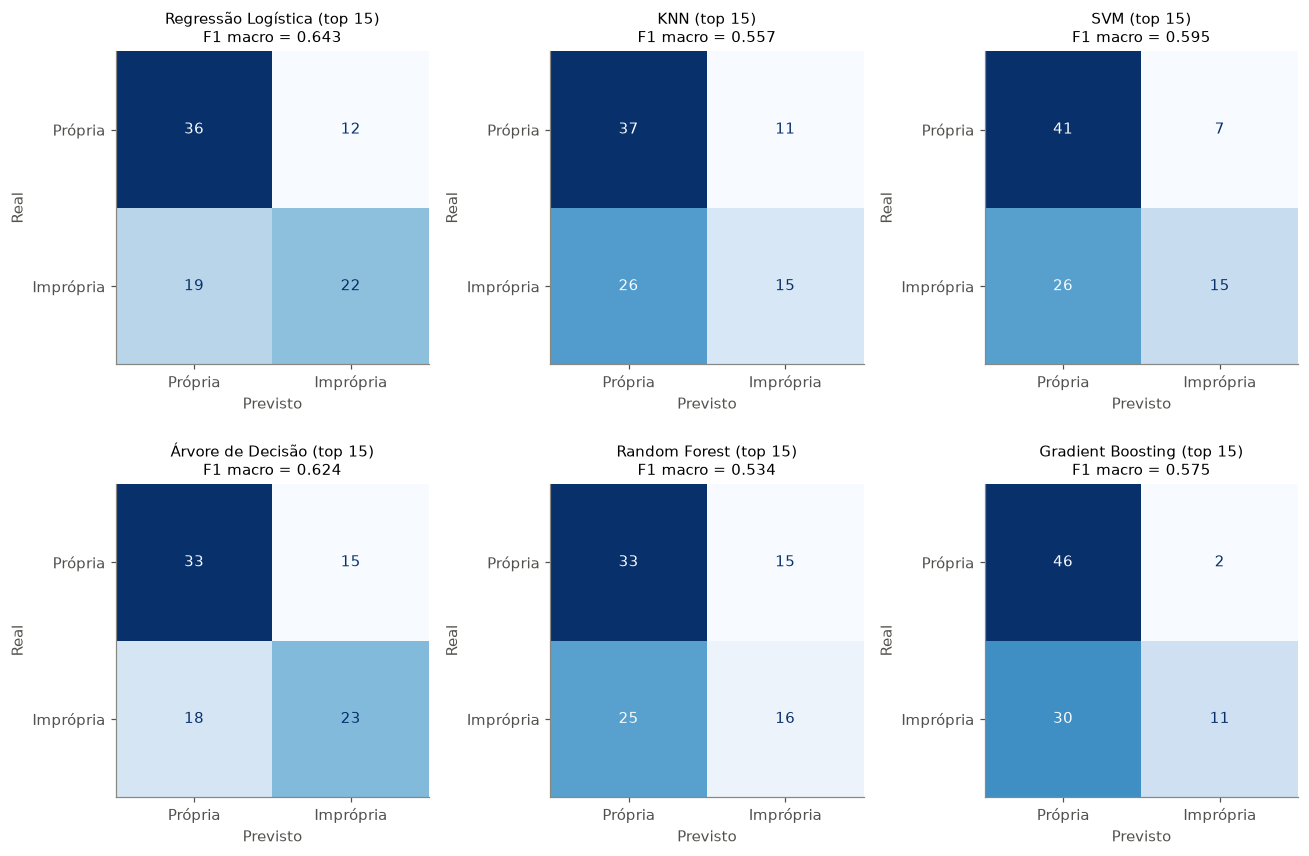

In [99]:
# matrizes de confusão com as 15 features
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (nome, y_pred) in zip(axes.flat, previsoes_top.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Própria", "Imprópria"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{nome} (top 15)\nF1 macro = {f1_score(y_test, y_pred, average='macro'):.3f}", fontsize=10)
    ax.set(xlabel="Previsto", ylabel="Real")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 14. O que o Random Forest aprendeu?

Com o Random Forest podemos utilizar um argumento feature_importance_ que é similar a ideia do feature_permutation mas acontence internamente dentro do algoritmo do RF

1. **Quais features mais influenciam** as previsões?
2. **Em que direção** elas influenciam (mais chuva → mais chance de imprópria?)

Usaremos três ferramentas:

| Ferramenta | Como funciona | Cuidado |
|---|---|---|
| **Importância por impureza** (`feature_importances_`) | soma quanto cada feature reduz a impureza (Gini) nas divisões de todas as árvores | calculada no treino; favorece features contínuas com muitos valores possíveis |
| **Dependência parcial** (*Partial Dependence*) | varia uma feature mantendo as outras e observa a probabilidade prevista | mostra a **direção** do efeito, na média |

In [115]:
pd.Series(finais["Random Forest"].named_steps["modelo"].feature_importances_, index=X_train.columns).sort_values(ascending=False)

tp_mm_day_1           0.059203
ssrd_mj_day_1         0.055660
swvl1_day_1           0.043933
tp_mm_sum_3d          0.034593
ssrd_mj_day_2         0.026952
wind_onshore_day_2    0.024993
t2m_c_day_4           0.024800
t2m_c_day_5           0.023316
ro_mm_day_1           0.022918
tp_mm_day_2           0.022050
tp_mm_sum_7d          0.021160
wind_speed_day_1      0.020664
t2m_c_day_1           0.020432
wind_onshore_day_1    0.020170
t2m_c_day_6           0.020061
ro_mm_day_2           0.019877
wind_onshore_day_3    0.019846
t2m_c_day_3           0.019645
wind_speed_day_6      0.019492
wind_speed_day_2      0.019405
ssrd_mj_day_7         0.019202
tp_mm_day_6           0.019162
t2m_c_day_2           0.018440
ro_mm_day_7           0.017060
ssrd_mj_day_6         0.016800
ssrd_mj_day_4         0.016448
tp_mm_day_3           0.016442
ssrd_mj_day_3         0.016254
swvl1_day_4           0.016156
wind_speed_day_5      0.016052
swvl1_day_7           0.015843
wind_onshore_day_6    0.015795
swvl1_da

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


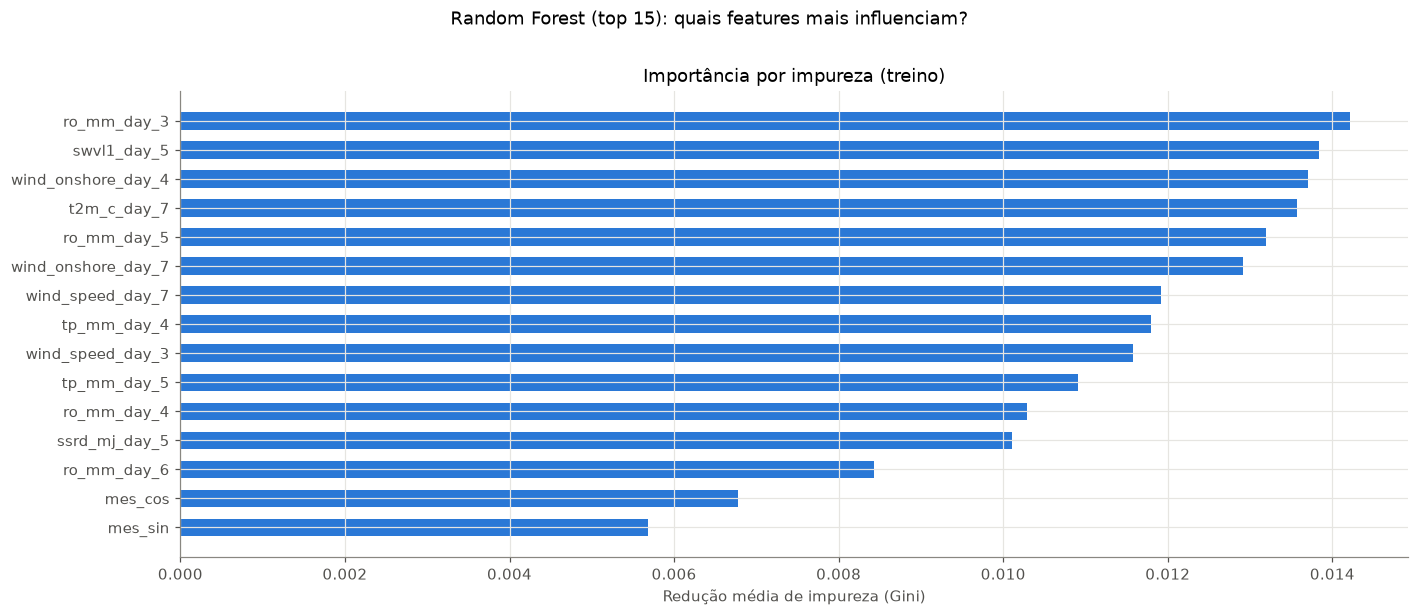

In [121]:
rf = finais_top["Random Forest"]

print(rf.named_steps["modelo"])   # hiperparâmetros escolhidos pelo Grid Search

# 1) importância por impureza
imp_impureza = pd.Series(finais["Random Forest"].named_steps["modelo"].feature_importances_, index=X_train.columns).sort_values(ascending=True)


ordem = imp_impureza.index[:15]
fig, axes = plt.subplots(1, 1, figsize=(13, 5.5), sharey=True)

axes.barh(ordem[:15], imp_impureza[ordem], color=AZUL, height=0.6)
axes.set(xlabel="Redução média de impureza (Gini)", title="Importância por impureza (treino)")

plt.suptitle("Random Forest (top 15): quais features mais influenciam?", y=1.01)
plt.tight_layout()
plt.show()

In [108]:
pd.Series(rf.named_steps["modelo"].feature_importances_)

0    0.117647
1    0.100715
2    0.094454
3    0.099800
4    0.139573
5    0.090960
6    0.091781
7    0.094452
8    0.086867
9    0.083751
dtype: float64

In [ ]:
rf = finais_top["Random Forest"]

print(rf.named_steps["modelo"])   # hiperparâmetros escolhidos pelo Grid Search

# 1) importância por impureza (vem pronta no modelo treinado)
imp_impureza = pd.Series(rf.named_steps["modelo"].feature_importances_, index=TOP_FEATURES)

# 2) importância por permutação no teste
perm = permutation_importance(rf, X_test_top, y_test, scoring=METRICA, n_repeats=50, random_state=SEED, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=TOP_FEATURES)
imp_perm_std = pd.Series(perm.importances_std, index=TOP_FEATURES)

ordem = imp_perm.sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

axes[0].barh(ordem, imp_impureza[ordem], color=AZUL, height=0.6)
axes[0].set(xlabel="Redução média de impureza (Gini)", title="Importância por impureza (treino)")

axes[1].barh(ordem, imp_perm[ordem], xerr=imp_perm_std[ordem], color=LARANJA, height=0.6,
             error_kw={"ecolor": TINTA, "lw": 1, "capsize": 2})
axes[1].axvline(0, color=CINZA, lw=1)
axes[1].set(xlabel="Queda do F1 macro ao embaralhar (média ± desvio)", title="Importância por permutação (teste)")

for ax in axes:
    ax.grid(axis="y", visible=False)
plt.suptitle("Random Forest (top 15): quais features mais influenciam?", y=1.01)
plt.tight_layout()
plt.show()

### Importância por tipo de variável

Cada variável aparece em vários dias da janela. Somando a importância de todos os dias de uma mesma
variável, vemos qual **fenômeno** pesa mais: chuva, sol, vento, temperatura ou sazonalidade.

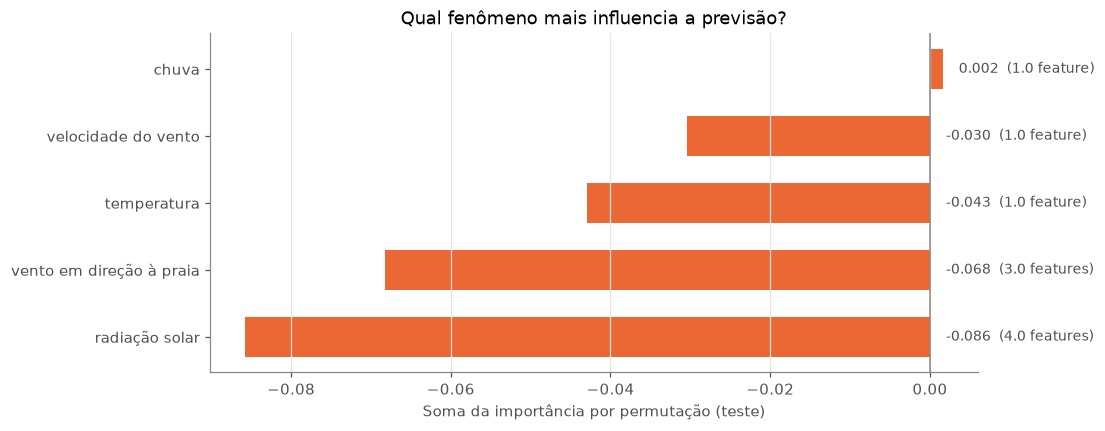

,impureza (treino),permutação (teste),nº de features
radiação solar,0.161,-0.086,4.0
vento em direção à praia,0.122,-0.068,3.0
temperatura,0.140,-0.043,1.0
velocidade do vento,0.114,-0.030,1.0
chuva,0.210,0.002,1.0
escoamento,0.106,NaN,NaN
sazonalidade (mês),0.012,NaN,NaN
umidade do solo,0.134,NaN,NaN


In [122]:
def tipo_variavel(feature):
    if feature.startswith("mes_"):
        return "sazonalidade (mês)"
    nomes = {"tp_mm": "chuva", "ro_mm": "escoamento", "swvl1": "umidade do solo", "t2m_c": "temperatura",
             "ssrd_mj": "radiação solar", "wind_speed": "velocidade do vento", "wind_onshore": "vento em direção à praia"}
    return nomes[feature.rsplit("_day_", 1)[0].split("_sum_")[0]]

por_tipo = pd.DataFrame({
    "impureza (treino)": imp_impureza.groupby(tipo_variavel).sum(),
    "permutação (teste)": imp_perm.groupby(tipo_variavel).sum(),
    "nº de features": imp_perm.groupby(tipo_variavel).size(),
}).sort_values("permutação (teste)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(por_tipo.index, por_tipo["permutação (teste)"], color=LARANJA, height=0.6)
for y, (v, n) in enumerate(zip(por_tipo["permutação (teste)"], por_tipo["nº de features"])):
    ax.text(max(v, 0) + 0.002, y, f"{v:.3f}  ({n} feature{'s' if n > 1 else ''})", va="center", fontsize=9, color=TINTA)
ax.axvline(0, color=CINZA, lw=1)
ax.set(xlabel="Soma da importância por permutação (teste)", title="Qual fenômeno mais influencia a previsão?")
ax.grid(axis="y", visible=False)
plt.show()

por_tipo.round(3)


## 16. Discussão

- **Sempre compare com um baseline.** O ganho real de um modelo é a distância até essa régua, não o valor absoluto.
- **Escolha a métrica pensando no problema.** Em classes desbalanceadas, prefira métricas que olham as duas
  classes (`f1_macro`, `balanced_accuracy`) ou decida qual erro é mais caro (FN = risco à saúde; FP = praia
  fechada à toa).
- **Escolha o modelo pela validação, avalie no teste.** Se escolhêssemos o "melhor no teste", o teste
  deixaria de ser uma estimativa honesta. Repare que o modelo escolhido pela validação não é necessariamente
  o de maior F1 no teste: com poucas amostras (89 no teste, 18 próprias), as diferenças entre modelos
  são pequenas e ruidosas. Todos superam o baseline, e isso é o que conseguimos afirmar com segurança.
- **Mais features não é sempre melhor.** Features redundantes (correlacionadas) somam ruído e risco de
  *overfitting* sem acrescentar informação. Selecione features **só com os dados de treino**.
- **Importância não é causalidade.** Os gráficos de importância e de dependência parcial mostram o que o
  modelo usa, não o que causa a contaminação. Use-os para levantar hipóteses e investigar.
- **O tempo muda a distribuição.** O teste (2019–2021) tem mais coletas impróprias que o treino
  (*distribution shift*), comum em dados ambientais.
- **O tempo explica só parte do problema.** Esgoto, maré, correntes e densidade de turistas não estão nas
  features, então não espere acurácia perfeita só com meteorologia.

### Exercícios

1. Mude o `LIMIAR` para 400 (limite de amostra única da CONAMA 274). O dataset fica mais balanceado? Os modelos melhoram em relação ao baseline?
2. Troque `METRICA` para `"balanced_accuracy"` ou `"recall"`. O que acontece com a matriz de confusão?
3. Use só as features de `day_1` e `day_2` (onde a correlação era maior). O desempenho cai?
4. Adicione um novo algoritmo (por exemplo `HistGradientBoostingClassifier` ou `MLPClassifier`) criando
   só mais uma entrada no dicionário `modelos`.